In [1]:
# — Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


In [2]:
# — Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# Quick summary / missing values
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [6]:
df.isna().sum()


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [7]:
#— Select features and target
feature_cols = ["MedInc", "AveRooms", "AveOccup", "HouseAge"]
target_col = "MedHouseVal"

X = df[feature_cols].values
y = df[target_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20640, 4)
y shape: (20640,)


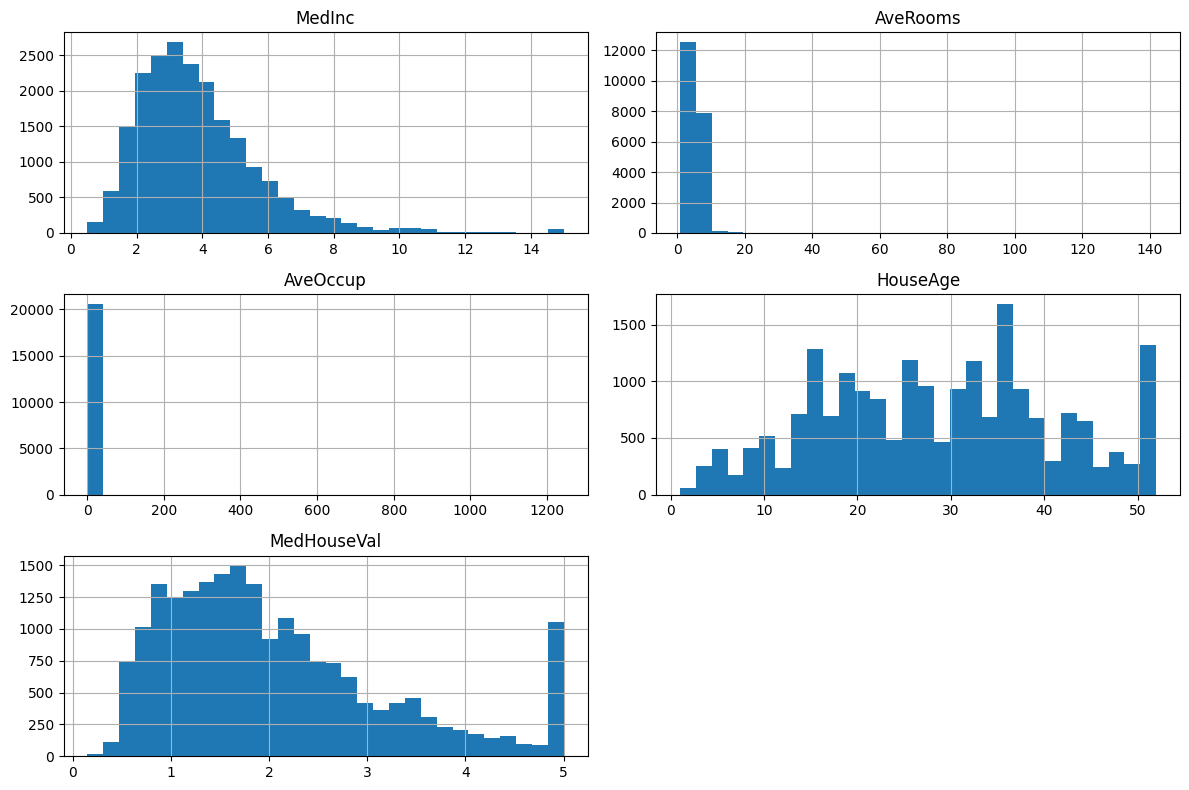

In [8]:
#— Simple EDA plots (distributions)
df[feature_cols + [target_col]].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

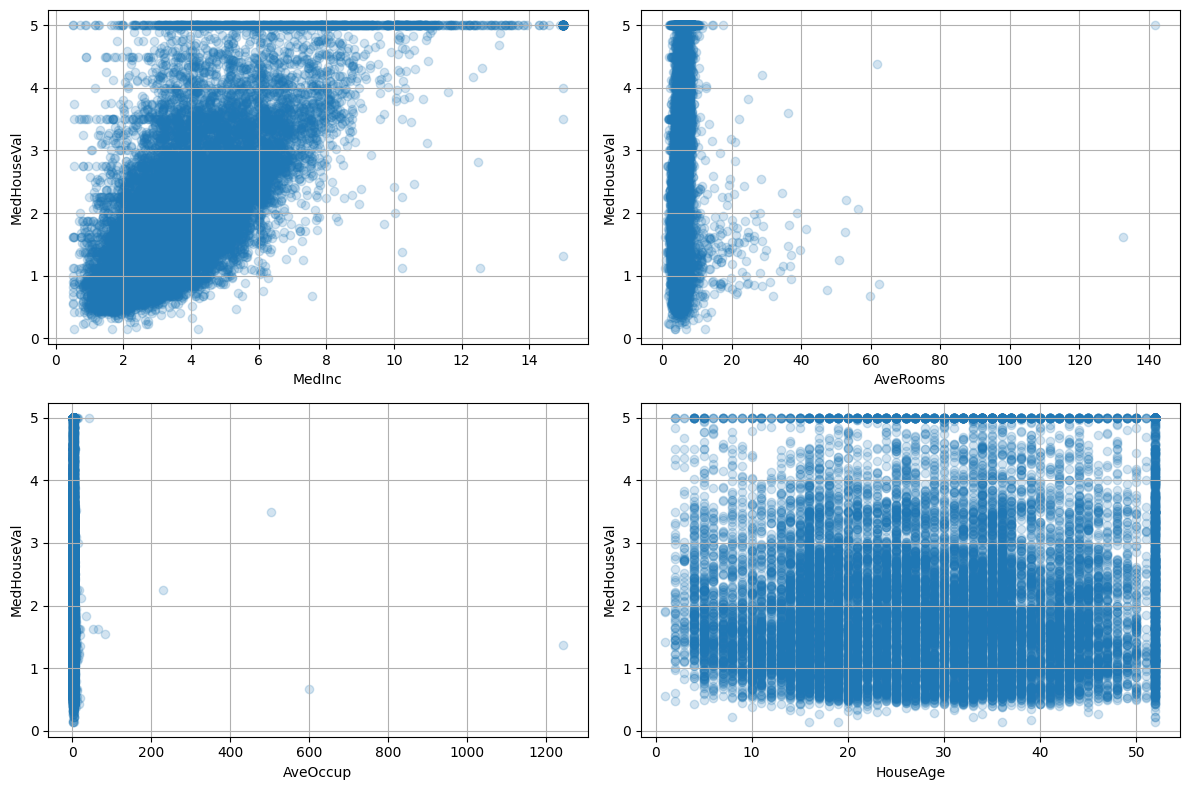

In [9]:
#-- Scatter plots vs target (spot relationships)
plt.figure(figsize=(12,8))
for i, col in enumerate(feature_cols):
    plt.subplot(2, 2, i+1)
    plt.scatter(df[col], df[target_col], alpha=0.2)
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
#— Train/test split (IMPORTANT: before normalization)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (16512, 4) (16512,)
Test : (4128, 4) (4128,)


In [11]:
#— Normalization utilities (Coursera-style)
def normalize_features(X):
    """
    Mean normalization:
    X_norm = (X - mu) / (max - min)
    Returns X_norm, mu, ptp
    """
    mu = np.mean(X, axis=0)
    ptp = np.ptp(X, axis=0)  # max - min
    X_norm = (X - mu) / ptp
    return X_norm, mu, ptp

def apply_normalization(X, mu, ptp):
    return (X - mu) / ptp


In [12]:
#— Fit normalization on train, apply to test
X_train_norm, mu, ptp = normalize_features(X_train)
X_test_norm = apply_normalization(X_test, mu, ptp)

print("mu:", mu)
print("ptp:", ptp)

print("PTP raw train:", np.ptp(X_train, axis=0))
print("PTP norm train:", np.ptp(X_train_norm, axis=0))

mu: [ 3.88075426  5.43523502  3.09696119 28.60828488]
ptp: [  14.5002      141.02020202 1242.64102564   51.        ]
PTP raw train: [  14.5002      141.02020202 1242.64102564   51.        ]
PTP norm train: [1. 1. 1. 1.]


In [13]:
#— Sanity checks after normalization
print("Train norm mean (approx 0):", np.mean(X_train_norm, axis=0))
print("Train norm min:", np.min(X_train_norm, axis=0))
print("Train norm max:", np.max(X_train_norm, axis=0))


Train norm mean (approx 0): [-8.64997505e-16  1.35600598e-16 -7.47674013e-19 -3.16015517e-18]
Train norm min: [-0.23315915 -0.03223897 -0.00193512 -0.54133892]
Train norm max: [0.76684085 0.96776103 0.99806488 0.45866108]


In [14]:
#— Optional: Create classification label for next notebook
threshold = np.median(y_train)  # use TRAIN median to avoid leakage
y_train_cls = (y_train > threshold).astype(int)
y_test_cls  = (y_test  > threshold).astype(int)

print("Classification threshold:", threshold)
print("Train class counts:", np.bincount(y_train_cls))
print("Test  class counts:", np.bincount(y_test_cls))

Classification threshold: 1.7985
Train class counts: [8256 8256]
Test  class counts: [2078 2050]


In [18]:
#— Save processed arrays 
import os

np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/X_test.npy", X_test)
np.save("../data/processed/y_train.npy", y_train)
np.save("../data/processed/y_test.npy", y_test)

np.save("../data/processed/X_train_norm.npy", X_train_norm)
np.save("../data/processed/X_test_norm.npy", X_test_norm)

np.save("../data/processed/mu.npy", mu)
np.save("../data/processed/ptp.npy", ptp)

np.save("../data/processed/y_train_cls.npy", y_train_cls)
np.save("../data/processed/y_test_cls.npy", y_test_cls)

print("../Saved processed files to data/processed/")

../Saved processed files to data/processed/
